# Rank Correlation Compared to the Initial Ranking
This notebook focuses on how consistent the produced rankings for different datasets are with the original ranking produced by a model

In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["usa_house","usa_house_old", "cervic_cancer", "adult", "old_adult"],
    "../data/",
)

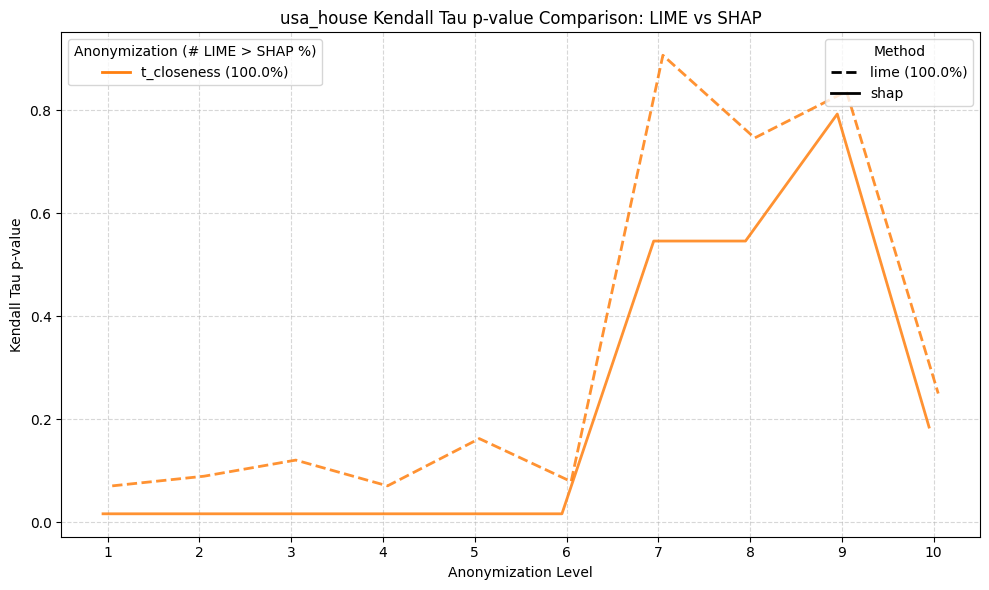

In [9]:
pl.plot_consistency("usa_house", ["t_closeness"])

So what does this plot show? It avverages all the p-values for each dataset thus producing a single p-value for dataset across different classifiers. What is interesting? That in this case, the Kendal tau's p-value between the initial ranking and the anonymized dataset for LIME is always higehr than that of SHAP. That means that here SHAP produces rankings that are more consistent, i.e. correlate, with the initial ranking produced. There is more statistical evidence for trusting a ranking produced by SHAP. It also neatly shows the instability of LIME, since it is quite wobbly compared to the one produced by SHAP. While this plot is nice and easy, let us try and consider a similar plot, but with all the annonymization methods

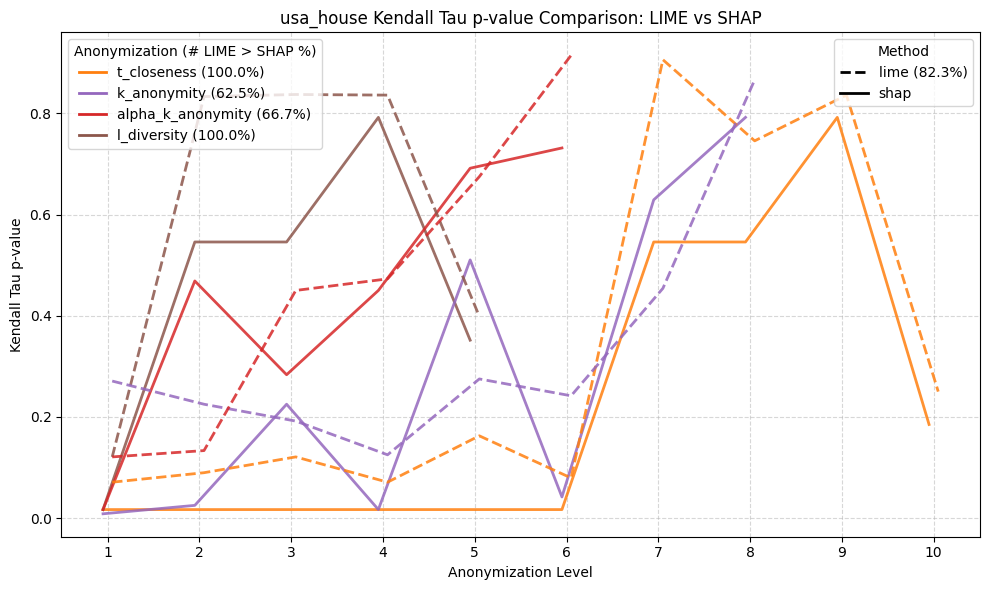

In [10]:
pl.plot_consistency("usa_house")

Now this picture is a bit more messy. But generally, we see that the p-value of SHAP is lower than that of LIME, further proving that SHAP is more consistent than LIME. Can we try and cast light on why k_anonymity and alpha_k_anonymity are so low compared to the other ones?

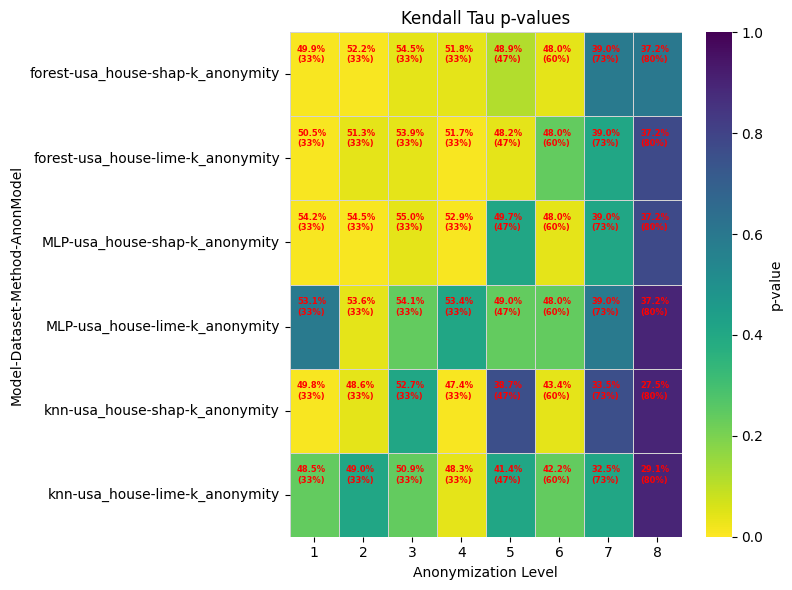

In [12]:
pl.plot_heatmap(["usa_house"],methods=["k_anonymity"])# ["MLP"])

Something nasty is happening at level=5. SHAP acts out on every model. Note, we again see that forest is slighly more stable. 

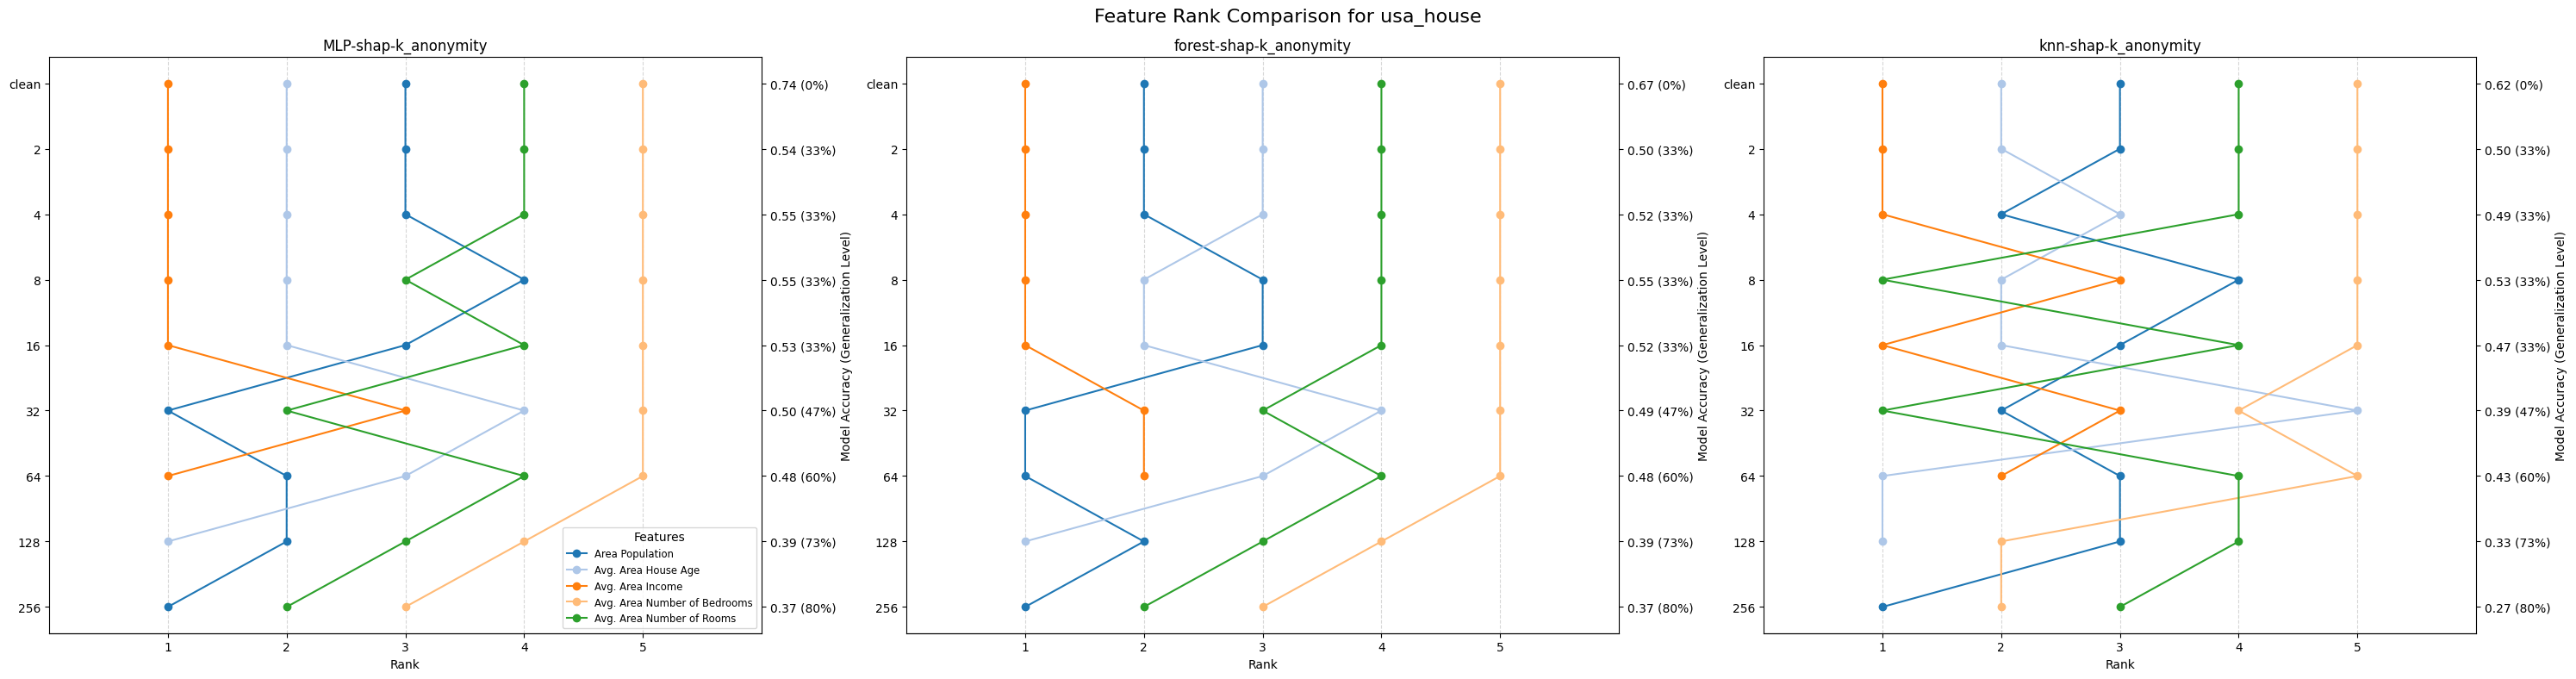

In [15]:
pl.plot_line_compare("usa_house", ["forest-shap-k_anonymity","MLP-shap-k_anonymity","knn-shap-k_anonymity"])

Interesting enough, here we see that forest is doing much better than knn and MLP at producing stable rankings. There is definetly big jump in generalization around step 5 which does affect the rankings quite a bit. 

Let us move on to the cervic cancer dataset

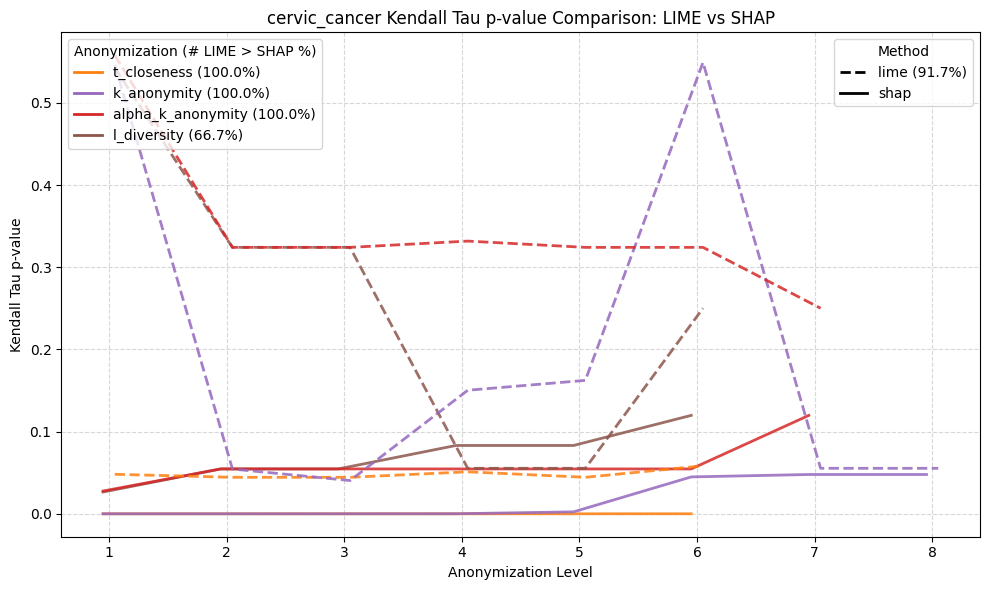

In [17]:
pl.plot_consistency("cervic_cancer")

This further shows that SHAP produces better rankings than LIME. However, it is rather impressive that for LIME almost all of the anonymization models starts out so high, aned then decreases considerably as the dataset is anonymized further. Why? Let us look at some line plots

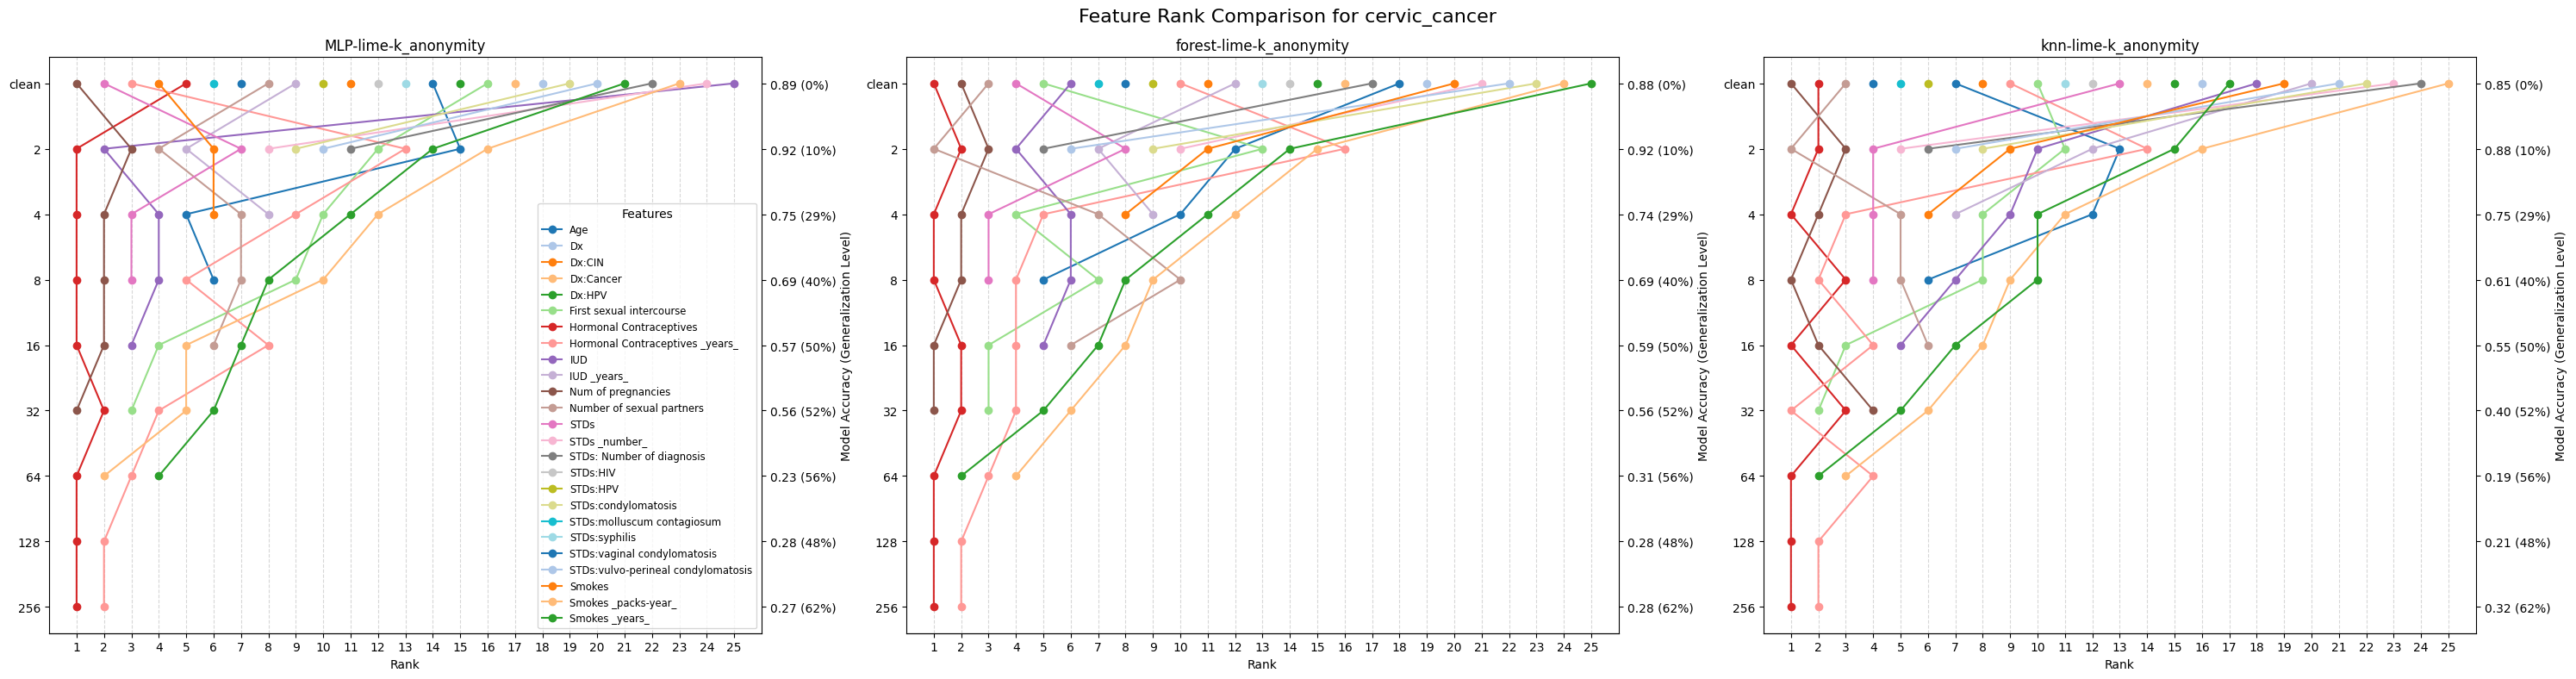

In [19]:
pl.plot_line_compare("cervic_cancer", ["forest-lime-k_anonymity","MLP-lime-k_anonymity","knn-lime-k_anonymity"])

We see that all the models tend to rank the features that are suppressed right away rather high, penalizing it quite a lot. As more and more features are suppressed, the suppressed features are all assigned a lower and lower rank (they are always all assigned the next available rank) which results in the p-value decreasing as more and more features are suppressed, since the initial important features become more and more "important".

Let us now consider SHAP to see why it performs so much better

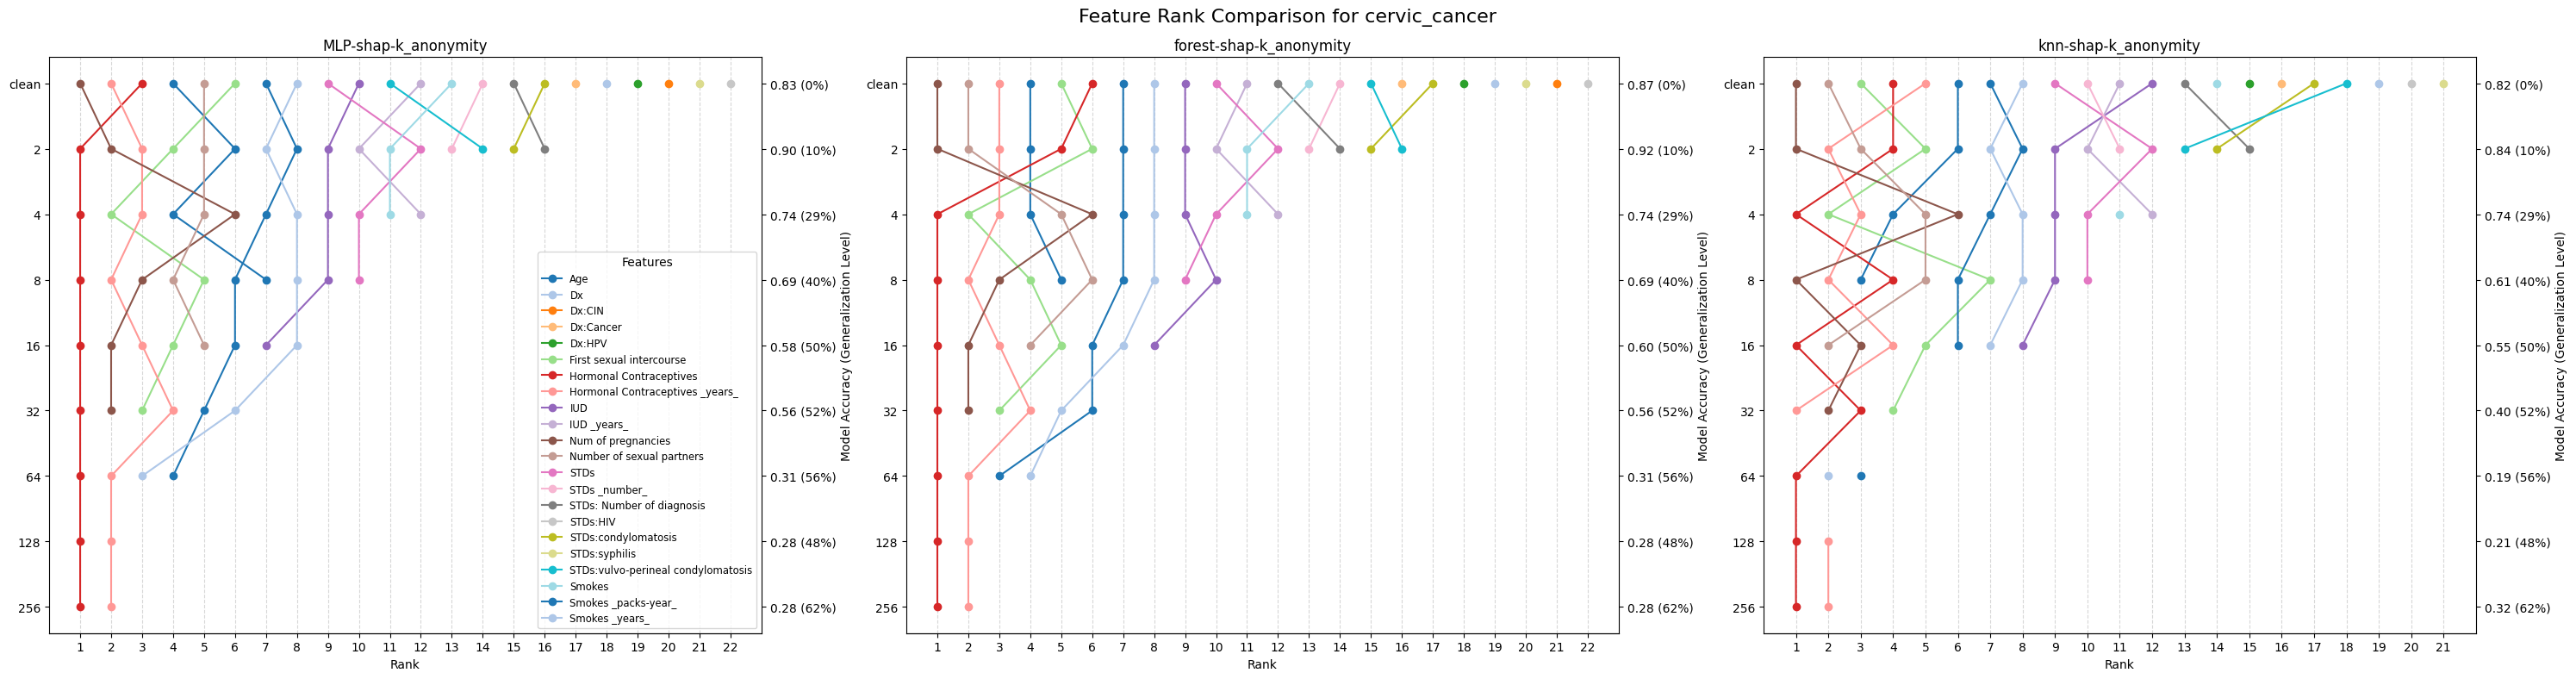

In [20]:
pl.plot_line_compare("cervic_cancer", ["forest-shap-k_anonymity","MLP-shap-k_anonymity","knn-shap-k_anonymity"])

First, note that it takes less features into account. Some features are simply deemed not important. For LIME, all features had a a non-zero importance for one of the representative explanation methods picked at some time. Generally the initial ranking of SHAP happens to be more aligned with the features that are not anonymized later on. This makes them have a much better ranking correlation overall.   
**Note** the weird ranking behavior of knn at level 16 and 32. For some reason they have missing feature importance. The data is correct, SHAP simply gives them a rank of 0. There has been other times where knn produces some nan ranks. This again shows that hierarchies have a huge effect on the produced rankings and that applying them to a specific level can lead to much different results.

Let us now consider the adult dataset

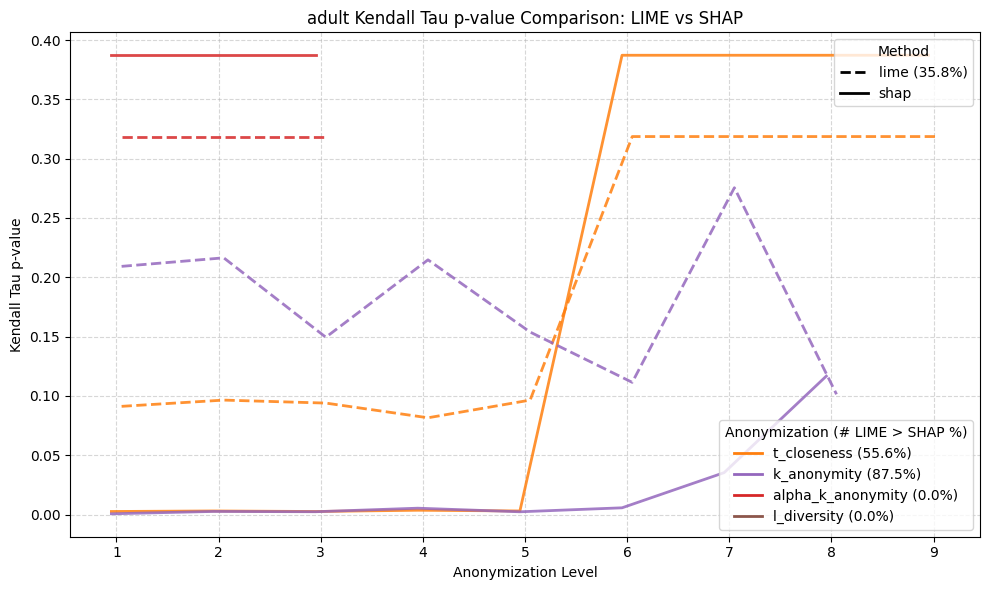

In [3]:
pl.plot_consistency("adult", legend_placement="lower right")

Now where is l_diversity? Only one dataset was produced, and therefore only one ranking was produced. That is not enough rankings to draw a line. It is present on the plot, however it is not shown since they are just points. See next plot for further details.  

While this plot contradicts the other findings, we choose to disregard l_diversity and alpha_k_anonymity because of the fact that the datasets are anonymized considerabley, and it chance that the featuer that LIME ranks as more important is the one that survives the generalization process. Why can we not make the same argument for LIME's case in the other cases, i.e. that it was just unlucky to give high rankings to the featurest that are anonymized initially? 
* In the case of USA_HOUSE we saw a similar behavoir acorss multiple datasets for which no features were fully suppressed, so it is not limited the same way

And that is most about it. I cannot really see any good reason for this method any more. The initial ranking is important, sure, but if features are completely removed from a dataset, it is rather random wether or not LIME does better than SHAP, because it all comes down to the fact which features are suppressed first. Cervic Cacncer showed that LIME was unlucky and here we see that SHAP is unlucky. It could show something interesting if there was meaning behind what features are anonymized, but since it depends on how the hieararchies are defined, which is rather arbitrary this is not the case. Again, this just shows that this way of doing generalizations are rather dangerous because you might loose the features that a explanation method deems important  

We are not all fucked. We should just in general disregard datasets that suppresses features quickly. Those datasets cannot really be used in the analysis. Another story is told for k_anonymity

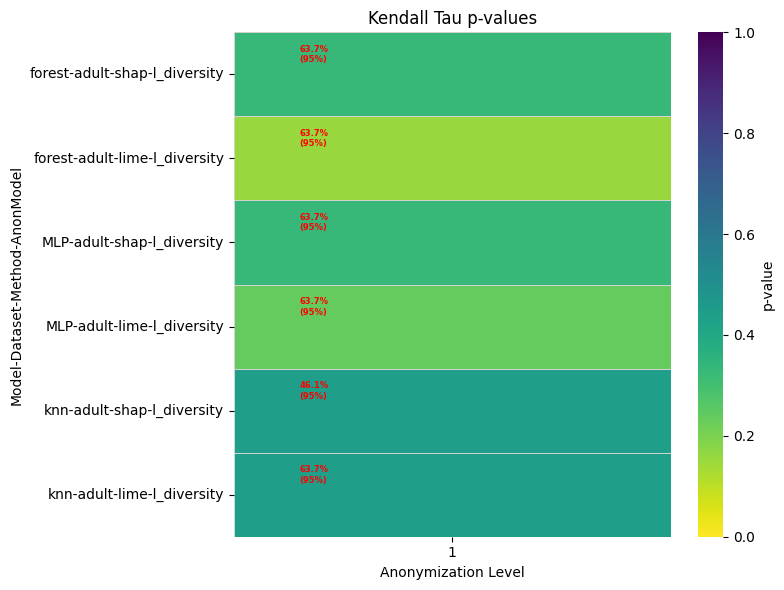

In [4]:
pl.plot_heatmap(["adult"],methods=["l_diversity"])# ["MLP"])

We see that LIME here outperforms SHAP. This in contrast to that we have seen earlier. Why?

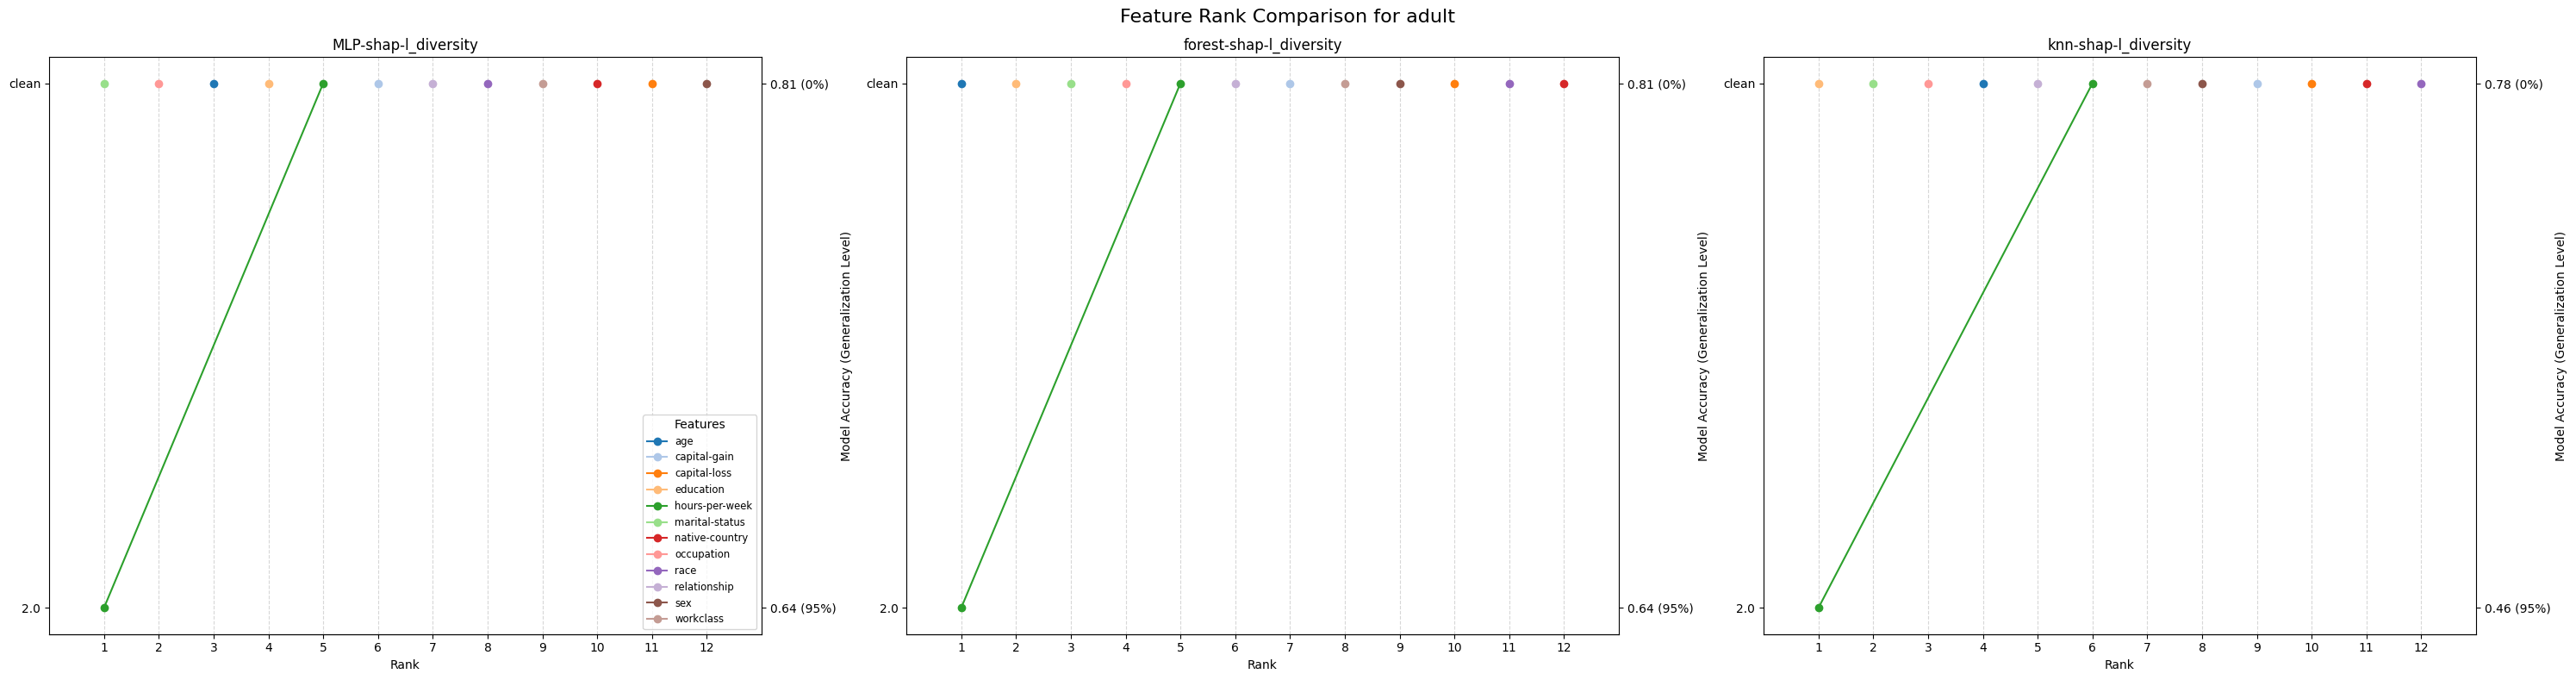

In [5]:
pl.plot_line_compare("adult", ["forest-shap-l_diversity","MLP-shap-l_diversity","knn-shap-l_diversity"])

Just like in alpha_k_anonymity all features have been suppressed, leaving only hours-per-week left. The reason the p-value varies, is because the initial ranking changes quickly. 

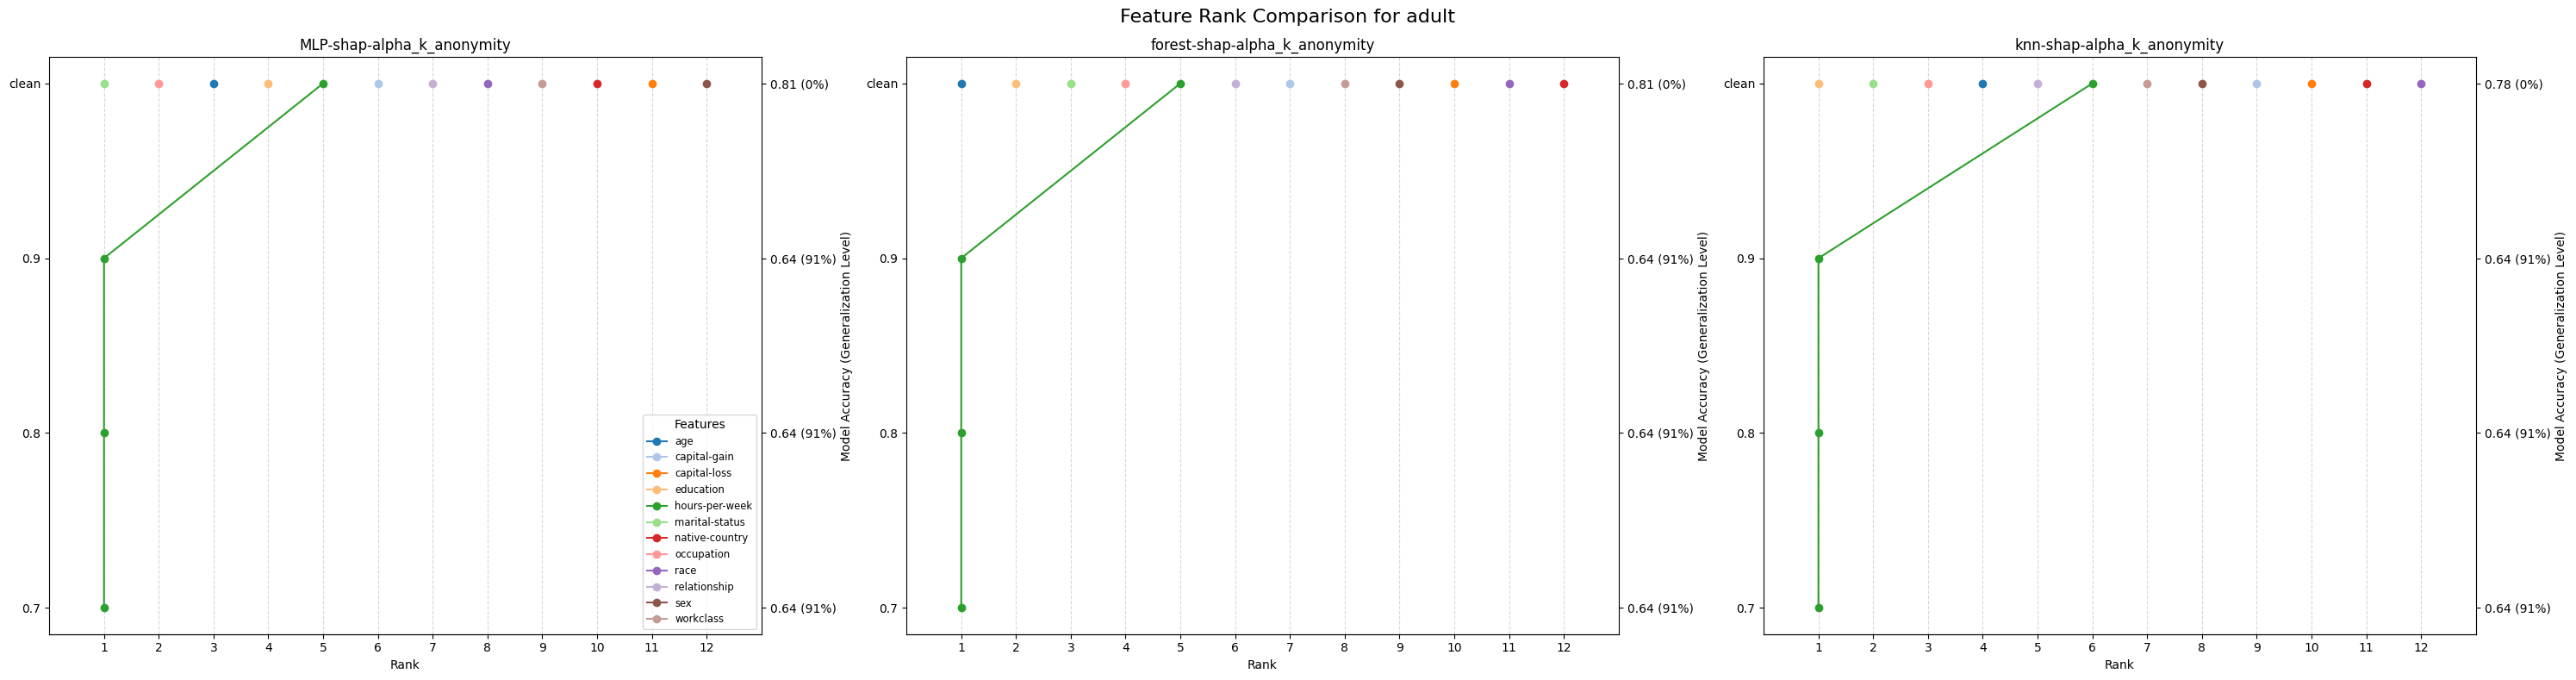

In [6]:
pl.plot_line_compare("adult", ["forest-shap-alpha_k_anonymity","MLP-shap-alpha_k_anonymity","knn-shap-alpha_k_anonymity"])

We see similar behaviour for alpha_k_anonymity. There is only one feature left to rank, and LIME just happens to rank that feature as more important

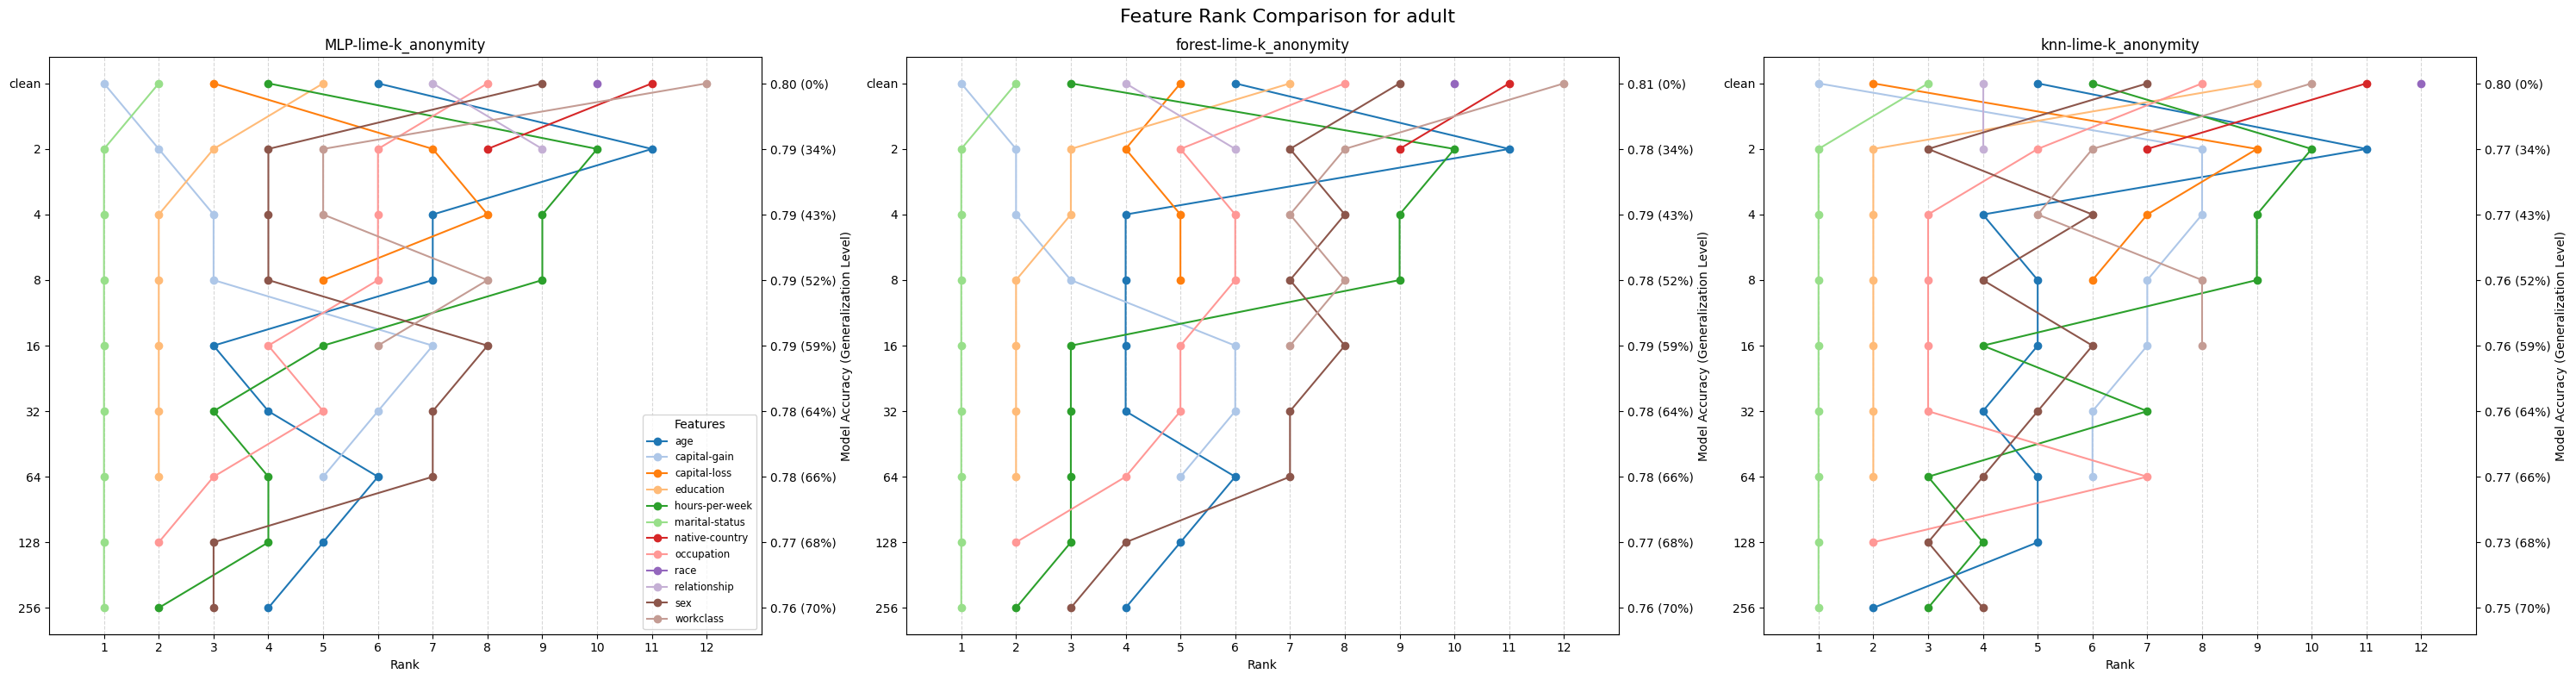

In [8]:
pl.plot_line_compare("adult", ["forest-lime-k_anonymity","MLP-lime-k_anonymity","knn-lime-k_anonymity"])

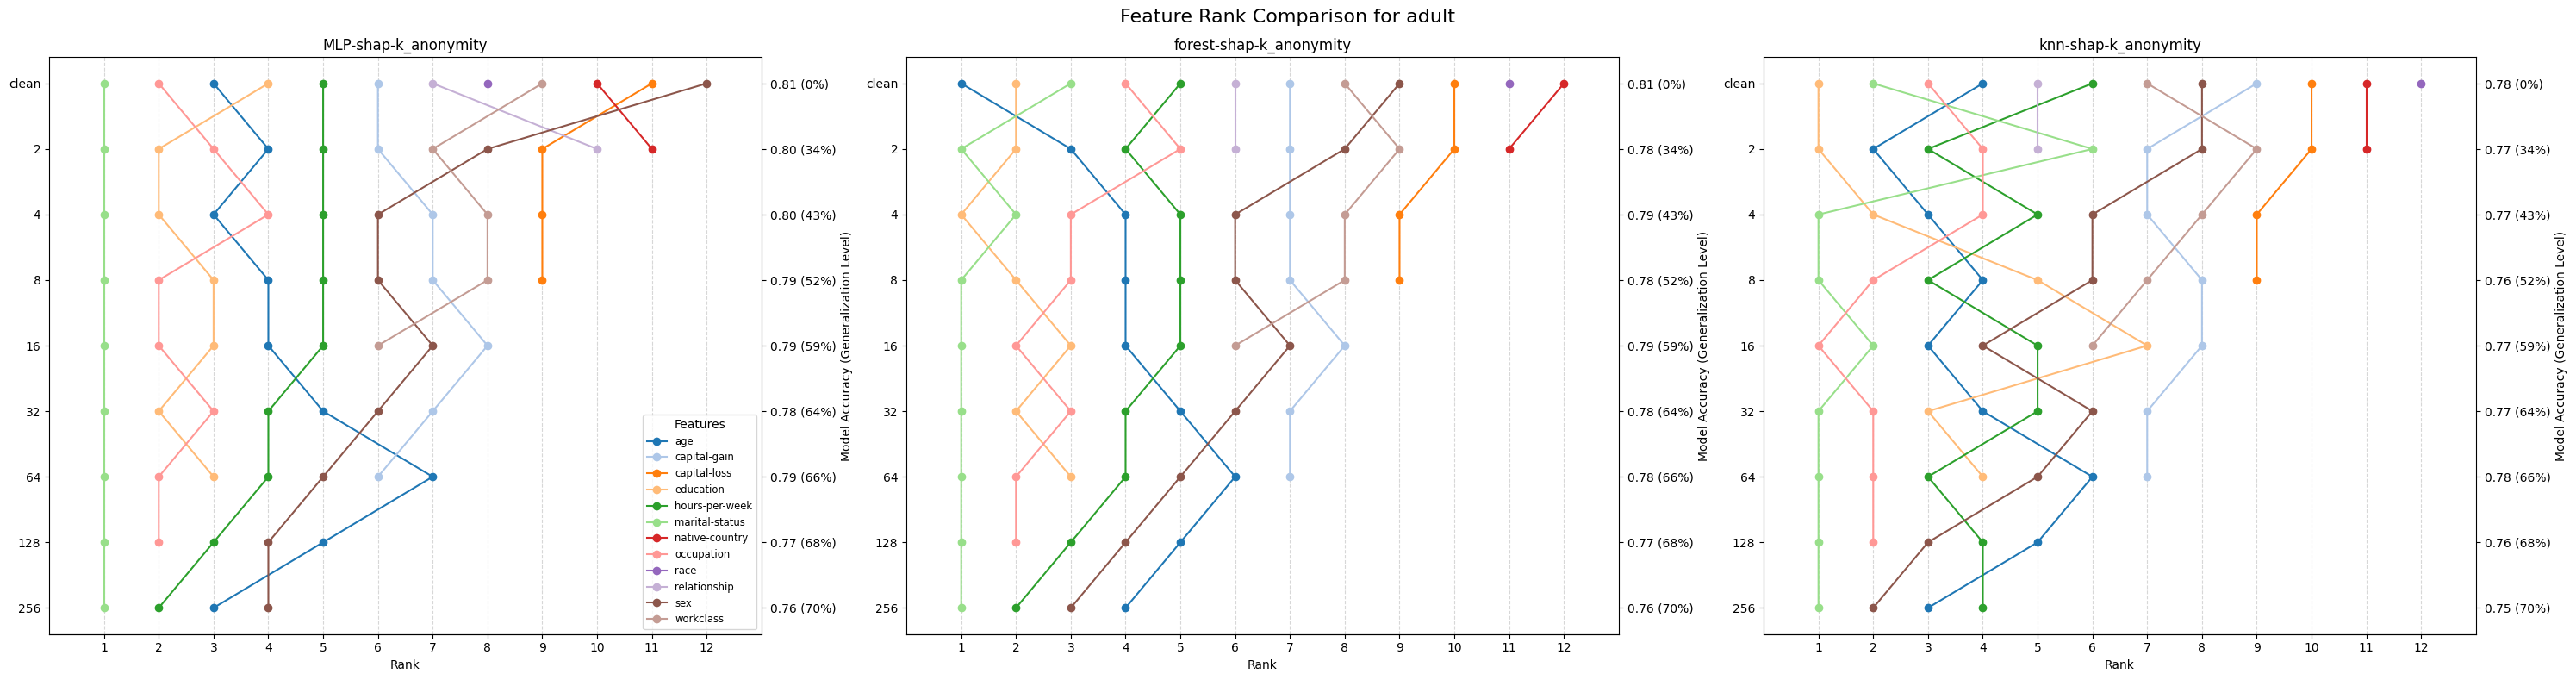

In [7]:
pl.plot_line_compare("adult", ["forest-shap-k_anonymity","MLP-shap-k_anonymity","knn-shap-k_anonymity"])